# 00 — Setup & Environment Check

**Purpose:** One-time setup. Run this before anything else.

It does three things:
1. Installs all Python libraries the project needs
2. Verifies the folder structure is intact
3. Confirms config files are in place

**No Bloomberg connection needed here. Runs entirely on your local PC.**

---

## 1. Install All Required Libraries
Run once. Safe to re-run — skips anything already installed.

In [1]:
import subprocess, sys

libraries = [
    "pandas",           # Core data manipulation
    "numpy",            # Numerical computing
    "matplotlib",       # Base plotting
    "seaborn",          # Correlation heatmaps and statistical plots
    "scipy",            # Statistical functions and distributions
    "scikit-learn",     # Regime classifier (used later)
    "statsmodels",      # Time series and regression
    "plotly",           # Interactive charts (used later)
    "openpyxl",         # Read/write Excel files if needed
    "tqdm",             # Progress bars
    "ipywidgets",       # Interactive widgets in notebooks
]

print("Installing libraries...\n")
all_ok = True
for lib in libraries:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", lib, "-q"],
        capture_output=True, text=True
    )
    status = "OK  " if result.returncode == 0 else "FAIL"
    if result.returncode != 0:
        all_ok = False
    print(f"  {status}  {lib}")

print()
print("All libraries installed." if all_ok else "Some installs failed — check FAIL lines above.")

Installing libraries...

  OK    pandas
  OK    numpy
  OK    matplotlib
  OK    seaborn
  OK    scipy
  OK    scikit-learn
  OK    statsmodels
  OK    plotly
  OK    openpyxl
  OK    tqdm
  OK    ipywidgets

All libraries installed.


## 2. Verify Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import statsmodels
import plotly

print("All imports successful.")
print()
print(f"  pandas        {pd.__version__}")
print(f"  numpy         {np.__version__}")
print(f"  matplotlib    {plt.matplotlib.__version__}")
print(f"  seaborn       {sns.__version__}")
print(f"  scipy         {scipy.__version__}")
print(f"  scikit-learn  {sklearn.__version__}")
print(f"  statsmodels   {statsmodels.__version__}")
print(f"  plotly        {plotly.__version__}")

All imports successful.

  pandas        2.3.3
  numpy         1.26.4
  matplotlib    3.10.6
  seaborn       0.13.2
  scipy         1.15.3
  scikit-learn  1.8.0
  statsmodels   0.14.5
  plotly        6.5.0


## 3. Verify Folder Structure and Config Files

In [3]:
import os, sys

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print(f"Project root: {PROJECT_ROOT}")
print()

folders_to_check = [
    ("data/raw/equities",           cfg.RAW_FOLDERS["equity"]),
    ("data/raw/volatility",         cfg.RAW_FOLDERS["volatility"]),
    ("data/raw/credit",             cfg.RAW_FOLDERS["credit"]),
    ("data/raw/rates",              cfg.RAW_FOLDERS["rates"]),
    ("data/raw/commodities",        cfg.RAW_FOLDERS["commodity"]),
    ("data/raw/fx",                 cfg.RAW_FOLDERS["fx"]),
    ("data/raw/macro_fundamentals", cfg.RAW_FOLDERS["macro"]),
    ("data/processed/returns",      os.path.join(cfg.PROC_PATH, "returns")),
    ("data/processed/aligned",      os.path.join(cfg.PROC_PATH, "aligned")),
    ("data/processed/regimes",      os.path.join(cfg.PROC_PATH, "regimes")),
    ("outputs/charts",              os.path.join(cfg.OUT_PATH,  "charts")),
    ("config",                      cfg.CONFIG_PATH),
]

config_files = [
    ("config/settings.py",          os.path.join(cfg.CONFIG_PATH, "settings.py")),
    ("config/tickers.csv",          os.path.join(cfg.CONFIG_PATH, "tickers.csv")),
    ("config/export_checklist.csv", os.path.join(cfg.CONFIG_PATH, "export_checklist.csv")),
]

all_ok = True

print("Folders:")
for label, path in folders_to_check:
    ok = os.path.isdir(path)
    if not ok: all_ok = False
    print(f"  {'OK  ' if ok else 'MISS'}  {label}")

print()
print("Config files:")
for label, path in config_files:
    ok = os.path.isfile(path)
    if not ok: all_ok = False
    print(f"  {'OK  ' if ok else 'MISS'}  {label}")

print()
if all_ok:
    print("Everything in place. You are ready to go.")
else:
    print("Some items missing — re-run create_folder_structure.py and re-place the config files.")

Project root: C:\Users\sarda\Desktop\GlobalMacroPulse

Folders:
  OK    data/raw/equities
  OK    data/raw/volatility
  OK    data/raw/credit
  OK    data/raw/rates
  OK    data/raw/commodities
  OK    data/raw/fx
  OK    data/raw/macro_fundamentals
  OK    data/processed/returns
  OK    data/processed/aligned
  OK    data/processed/regimes
  OK    outputs/charts
  OK    config

Config files:
  OK    config/settings.py
  OK    config/tickers.csv
  OK    config/export_checklist.csv

Everything in place. You are ready to go.


## 4. Confirm Settings

In [4]:
print("Key settings:")
print(f"  BASE_PATH        : {cfg.BASE_PATH}")
print(f"  ANCHOR_TIME      : {cfg.ANCHOR_TIME} ({cfg.ANCHOR_TZ})")
print(f"  RETURN_TYPE      : {cfg.RETURN_TYPE}")
print(f"  BBG_START_DATE   : {cfg.BBG_START_DATE}")
print(f"  Rolling windows  : {cfg.WINDOWS}")
print(f"  Regime labels    : {cfg.REGIME_LABELS}")
print()
print(f"  Market sequence  : {len(cfg.MARKET_SEQUENCE)} markets defined")
print(f"  First market     : {cfg.MARKET_SEQUENCE[0][0]} @ {cfg.MARKET_SEQUENCE[0][2]} UTC")
print(f"  Last market      : {cfg.MARKET_SEQUENCE[-1][0]} @ {cfg.MARKET_SEQUENCE[-1][2]} UTC")

Key settings:
  BASE_PATH        : C:\Users\sarda\Desktop\GlobalMacroPulse
  ANCHOR_TIME      : 17:00 (America/New_York)
  RETURN_TYPE      : log
  BBG_START_DATE   : 19900101
  Rolling windows  : {'short': 21, 'medium': 63, 'long': 252, 'verylong': 756}
  Regime labels    : ['risk_on', 'risk_off', 'transitional', 'crisis']

  Market sequence  : 20 markets defined
  First market     : NZX 50 @ 21:00 UTC
  Last market      : NASDAQ @ 14:30 UTC


## 5. Quick Matplotlib Sanity Check

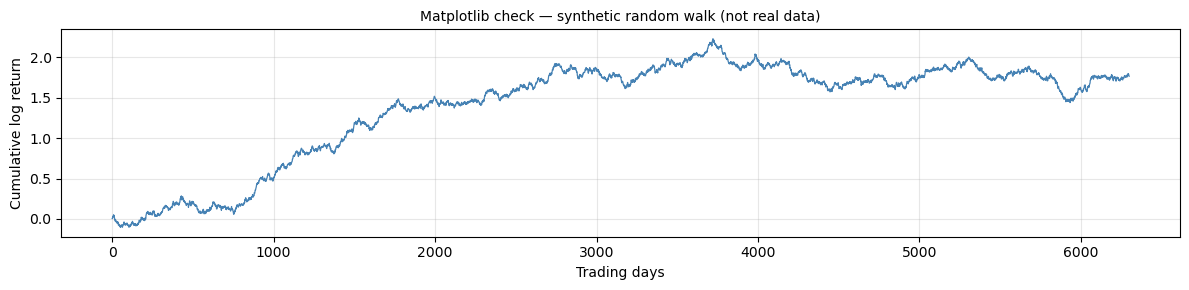

If you see a chart above — plotting is working correctly.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
fake_rets  = np.random.normal(0.0003, 0.01, 252 * 25)
cumulative = np.cumsum(fake_rets)

plt.figure(figsize=(12, 3))
plt.plot(cumulative, linewidth=0.9, color="steelblue")
plt.title("Matplotlib check — synthetic random walk (not real data)", fontsize=10)
plt.xlabel("Trading days")
plt.ylabel("Cumulative log return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("If you see a chart above — plotting is working correctly.")

---
## Setup Complete ✓

**Next steps:**
1. Head to NYU Bloomberg terminal
2. Work through **Session 1** of `config/export_checklist.csv` (21 tickers, ~45 mins)
3. Email yourself the zip, extract files to `data/raw/volatility/` and `data/raw/credit/`
4. Open `notebooks/01_data_pipeline/01_data_pipeline.ipynb` and run it

The pipeline processes whatever files exist and skips the rest — run it after every terminal session to incrementally build up the dataset.